# Stage 2 - Motion Artifact Removal (Simple Version)

Goal: clean green PPG during motion using IR as reference.

I only use two required files from one participant:
- walking
- running

I keep this notebook short:
1. load files
2. compare raw green vs IR
3. do simple IR-reference subtraction after bandpass
4. detect beats + HR/HRV
5. compare to Zephyr HR summary

## Why frequency view helps

In time domain, motion and pulse are mixed.
In frequency domain, motion is usually stronger at low frequencies, so it is easier to see what to suppress.

In [1]:
from pathlib import Path
import importlib.util

required = ['numpy', 'scipy', 'pandas', 'matplotlib']
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    raise ImportError(
        f"Missing required packages: {missing}. Install once in system Python and re-run."
    )

dataset_dir = Path('Dataset')
if not dataset_dir.exists():
    raise FileNotFoundError(
        "Dataset folder not found. Put the extracted Dataset folder in assignment_2 and re-run."
    )

print('Dataset ready at:', dataset_dir.resolve())

Dataset ready at: /home/odin/achal/Pervasive-Computing-for-Health/assignment_2/Dataset


In [2]:
from pathlib import Path
print('Zip exists:', Path('EarSet_v1.zip').exists())
print('Dataset exists:', Path('Dataset').exists())

Zip exists: True
Dataset exists: True


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from pathlib import Path
import warnings
import importlib.util
warnings.filterwarnings('ignore')

RUN_HEARTPY = False  # keep False for stable run-all
HEARTPY_AVAILABLE = importlib.util.find_spec('heartpy') is not None
if RUN_HEARTPY and HEARTPY_AVAILABLE:
    import heartpy as hp

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

dataset_path = Path('./Dataset')
participant_id = '26'
ear = 'left'
conditions = ['walking', 'running']
fs = 100

print('Stage 2 pipeline')
print(f'Participant: P{participant_id}, ear={ear}, conditions={conditions}')

Stage 2 pipeline
Participant: P26, ear=left, conditions=['walking', 'running']


## Load movement data

Files used in this notebook:
- `Dataset/P26/EARBUDS/26-walking-ppg-left.csv`
- `Dataset/P26/EARBUDS/26-running-ppg-left.csv`
- `Dataset/P26/ZEPHYR/26_Summary.csv`

That satisfies the assignment rule (one walking + one running file).

In [4]:
def load_condition_data(pid: str, cond: str, ear_side: str = 'left'):
    ppg_file = dataset_path / f'P{pid}' / 'EARBUDS' / f'{pid}-{cond}-ppg-{ear_side}.csv'
    imu_file = dataset_path / f'P{pid}' / 'EARBUDS' / f'{pid}-{cond}-imu-{ear_side}.csv'
    zephyr_file = dataset_path / f'P{pid}' / 'ZEPHYR' / f'{pid}_Summary.csv'

    ppg_df = pd.read_csv(ppg_file)
    imu_df = pd.read_csv(imu_file)
    ze_df = pd.read_csv(zephyr_file)

    ppg_df['timestamp_num'] = pd.to_numeric(ppg_df['timestamp'].astype(str).str.replace('#', '', regex=False), errors='coerce')
    for col in ['green', 'ir', 'red']:
        ppg_df[col] = pd.to_numeric(ppg_df[col], errors='coerce').interpolate(limit_direction='both')

    return {
        'ppg_file': ppg_file,
        'imu_file': imu_file,
        'zephyr_file': zephyr_file,
        'ppg': ppg_df,
        'imu': imu_df,
        'zephyr': ze_df
    }

data = {c: load_condition_data(participant_id, c, ear) for c in conditions}

for c in conditions:
    d = data[c]
    print(f"\n{c.upper()} files")
    print('  PPG   :', d['ppg_file'])
    print('  IMU   :', d['imu_file'])
    print('  ZEPHYR:', d['zephyr_file'])
    print('  PPG samples:', len(d['ppg']))


WALKING files
  PPG   : Dataset/P26/EARBUDS/26-walking-ppg-left.csv
  IMU   : Dataset/P26/EARBUDS/26-walking-imu-left.csv
  ZEPHYR: Dataset/P26/ZEPHYR/26_Summary.csv
  PPG samples: 12006

RUNNING files
  PPG   : Dataset/P26/EARBUDS/26-running-ppg-left.csv
  IMU   : Dataset/P26/EARBUDS/26-running-imu-left.csv
  ZEPHYR: Dataset/P26/ZEPHYR/26_Summary.csv
  PPG samples: 12004


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

for i, c in enumerate(conditions):
    ppg_df = data[c]['ppg']
    t = (ppg_df['timestamp_num'] - ppg_df['timestamp_num'].iloc[0]) / 1000.0
    use = t <= 30

    axes[i, 0].plot(t[use], ppg_df.loc[use, 'green'], 'g-', linewidth=0.8)
    axes[i, 0].set_title(f'{c.capitalize()} - Raw Green PPG (30 s)')
    axes[i, 0].set_ylabel('Amplitude (a.u.)')
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(t[use], ppg_df.loc[use, 'ir'], 'b-', linewidth=0.8)
    axes[i, 1].set_title(f'{c.capitalize()} - IR Reference (30 s)')
    axes[i, 1].grid(alpha=0.3)

axes[1, 0].set_xlabel('Time (s)')
axes[1, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

AttributeError: 'RcParams' object has no attribute '_get'

## Pipeline

- bandpass green + IR (0.5-5 Hz)
- normalize both
- estimate average green-IR correlation in 10 s windows
- clean = green - corr*IR
- run peak detection and HRV
- compare HR against Zephyr (MAE + correlation)

In [ ]:
def bandpass_filter(x, fs_hz, low=0.5, high=5.0, order=4):
    sos = signal.butter(order, [low/(fs_hz/2), high/(fs_hz/2)], btype='band', output='sos')
    y = signal.sosfiltfilt(sos, x)
    return y

def normalize(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-10)

def detect_beats(x, fs_hz):
    h = np.mean(x) + 0.4*np.std(x)
    d = int(0.35 * fs_hz)
    peaks, _ = find_peaks(x, height=h, distance=d)
    if len(peaks) < 2:
        return peaks, np.array([]), np.array([])
    rr_ms = np.diff(peaks) / fs_hz * 1000.0
    hr_inst = 60000.0 / rr_ms
    t_hr = peaks[1:] / fs_hz
    return peaks, t_hr, hr_inst

def hrv_time_domain(rr_ms):
    if len(rr_ms) < 2:
        return dict(sdnn=np.nan, pnn50=np.nan, rmssd=np.nan)
    diffs = np.diff(rr_ms)
    sdnn = float(np.std(rr_ms, ddof=1)) if len(rr_ms) > 1 else np.nan
    pnn50 = float(100*np.mean(np.abs(diffs) > 50))
    rmssd = float(np.sqrt(np.mean(diffs**2)))
    return dict(sdnn=sdnn, pnn50=pnn50, rmssd=rmssd)

def lfhf_ratio(rr_ms):
    if len(rr_ms) < 8:
        return np.nan
    rr_t = np.cumsum(rr_ms)/1000.0
    t_reg = np.arange(0, rr_t[-1], 0.25)
    if len(t_reg) < 16:
        return np.nan
    rr_interp = np.interp(t_reg, rr_t, rr_ms)
    f, pxx = signal.welch(rr_interp, fs=4.0, nperseg=min(256, len(rr_interp)))
    lf = (f >= 0.04) & (f <= 0.15)
    hf = (f >= 0.15) & (f <= 0.40)
    lf_p = np.trapz(pxx[lf], f[lf]) if np.any(lf) else np.nan
    hf_p = np.trapz(pxx[hf], f[hf]) if np.any(hf) else np.nan
    return float(lf_p/hf_p) if np.isfinite(lf_p) and np.isfinite(hf_p) and hf_p > 0 else np.nan

def compare_to_zephyr(ze_df, t0_ms, t_hr_sec, hr_inst):
    if len(t_hr_sec) == 0:
        return np.nan, np.nan
    zt = pd.to_numeric(ze_df['Timestamp'], errors='coerce').values
    zhr = pd.to_numeric(ze_df['HR'], errors='coerce').values
    valid = np.isfinite(zt) & np.isfinite(zhr)
    zt, zhr = zt[valid], zhr[valid]
    if len(zt) < 2:
        return np.nan, np.nan
    abs_t = t0_ms + t_hr_sec*1000.0
    mask = (abs_t >= zt.min()) & (abs_t <= zt.max())
    if np.sum(mask) < 3:
        return np.nan, np.nan
    ref = np.interp(abs_t[mask], zt, zhr)
    est = hr_inst[mask]
    mae = float(np.mean(np.abs(est - ref)))
    corr = float(np.corrcoef(est, ref)[0, 1]) if len(est) > 2 else np.nan
    return mae, corr

In [ ]:
results = {}

for cond in conditions:
    ppg_df = data[cond]['ppg']
    ze_df = data[cond]['zephyr']

    green = ppg_df['green'].values.astype(float)
    ir = ppg_df['ir'].values.astype(float)
    t0 = float(ppg_df['timestamp_num'].iloc[0])
    t = (ppg_df['timestamp_num'] - ppg_df['timestamp_num'].iloc[0]).values / 1000.0

    green_bp = normalize(bandpass_filter(green, fs))
    ir_bp = normalize(bandpass_filter(ir, fs))

    w = int(10 * fs)
    corrs = []
    for i in range(0, len(green_bp)-w, w):
        c = np.corrcoef(green_bp[i:i+w], ir_bp[i:i+w])[0, 1]
        if np.isfinite(c):
            corrs.append(c)
    avg_corr = float(np.mean(corrs)) if len(corrs) else 0.0

    ir_ref_clean = green_bp - avg_corr * ir_bp

    # Ignore first/last 1s to avoid filter-edge transients in beat metrics
    edge = fs
    green_eval = green_bp[edge:-edge]
    clean_eval = ir_ref_clean[edge:-edge]

    p1_local, t1_local, hr1 = detect_beats(green_eval, fs)
    p1 = p1_local + edge
    t1 = t1_local + (edge / fs)
    rr1 = np.diff(p1)/fs*1000.0 if len(p1) > 1 else np.array([])
    hrv1 = hrv_time_domain(rr1)
    hrv1['lf_hf'] = lfhf_ratio(rr1)
    mae1, corr1 = compare_to_zephyr(ze_df, t0, t1, hr1)

    p2_local, t2_local, hr2 = detect_beats(clean_eval, fs)
    p2 = p2_local + edge
    t2 = t2_local + (edge / fs)
    rr2 = np.diff(p2)/fs*1000.0 if len(p2) > 1 else np.array([])
    hrv2 = hrv_time_domain(rr2)
    hrv2['lf_hf'] = lfhf_ratio(rr2)
    mae2, corr2 = compare_to_zephyr(ze_df, t0, t2, hr2)

    hp_metrics = {'bpm': np.nan, 'sdnn': np.nan, 'pnn50': np.nan, 'rmssd': np.nan, 'lf_hf': np.nan}
    mae3, corr3 = np.nan, np.nan
    if RUN_HEARTPY and HEARTPY_AVAILABLE:
        wd, ms = hp.process(clean_eval, sample_rate=fs, bpmmin=35, bpmmax=200)
        hp_metrics['bpm'] = float(ms.get('bpm', np.nan))
        hp_metrics['sdnn'] = float(ms.get('sdnn', np.nan))
        hp_metrics['pnn50'] = float(ms.get('pnn50', np.nan))
        hp_metrics['rmssd'] = float(ms.get('rmssd', np.nan))

    gt_mask = (ze_df['Timestamp'] >= ppg_df['timestamp_num'].min()) & (ze_df['Timestamp'] <= ppg_df['timestamp_num'].max())
    gt_hr = float(pd.to_numeric(ze_df.loc[gt_mask, 'HR'], errors='coerce').mean()) if gt_mask.any() else np.nan

    results[cond] = {
        'time_sec': t,
        'green_raw': green,
        'ir_raw': ir,
        'green_bp': green_bp,
        'ir_ref_clean': ir_ref_clean,
        'peaks_bp': p1,
        'peaks_clean': p2,
        'avg_corr_green_ir': avg_corr,
        'gt_hr_mean': gt_hr,
        'metrics': [
            {'method': 'Bandpass only', 'HR_bpm': float(np.mean(hr1)) if len(hr1) else np.nan, **hrv1, 'MAE_vs_gt': mae1, 'Corr_vs_gt': corr1},
            {'method': 'IR-reference cleaned', 'HR_bpm': float(np.mean(hr2)) if len(hr2) else np.nan, **hrv2, 'MAE_vs_gt': mae2, 'Corr_vs_gt': corr2},
            {'method': 'HeartPy reference', 'HR_bpm': hp_metrics['bpm'], 'sdnn': hp_metrics['sdnn'], 'pnn50': hp_metrics['pnn50'], 'rmssd': hp_metrics['rmssd'], 'lf_hf': hp_metrics['lf_hf'], 'MAE_vs_gt': mae3, 'Corr_vs_gt': corr3}
        ]
    }

print('Done processing:', list(results.keys()))

Done processing: ['walking', 'running']


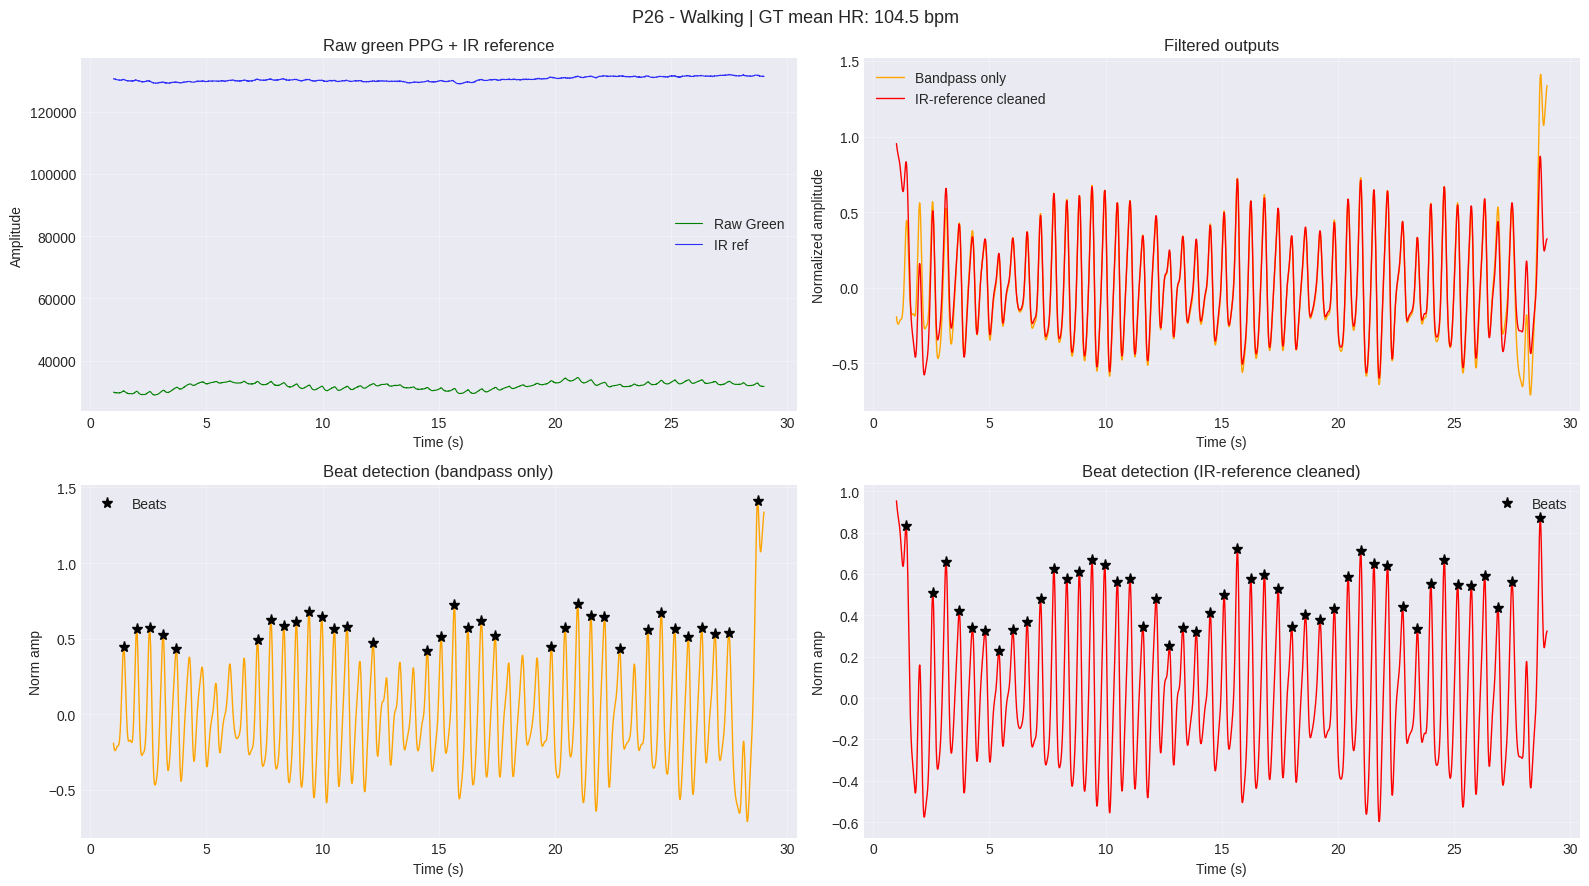

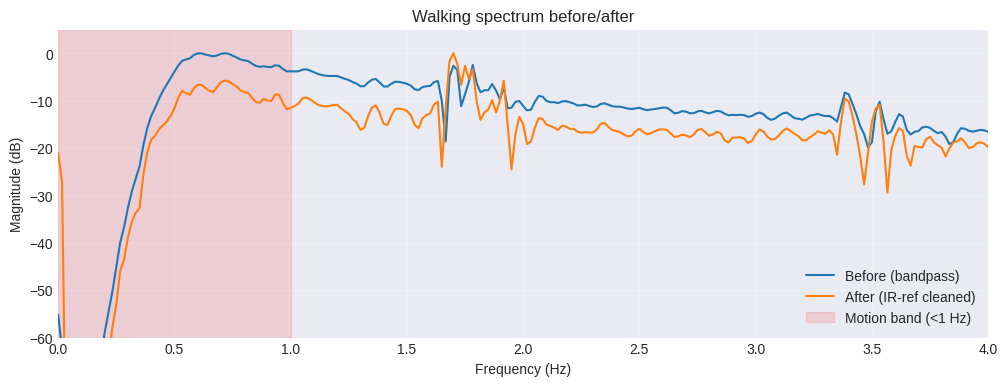


WALKING metrics


,method,HR_bpm,sdnn,pnn50,rmssd,lf_hf,MAE_vs_gt,Corr_vs_gt
0,Bandpass only,93.438,728.329,32.394,1029.819,0.633,13.787,0.054
1,IR-reference cleaned,102.185,140.025,15.544,192.150,1.107,5.374,0.307
2,HeartPy reference,NaN,NaN,NaN,NaN,NaN,NaN,NaN


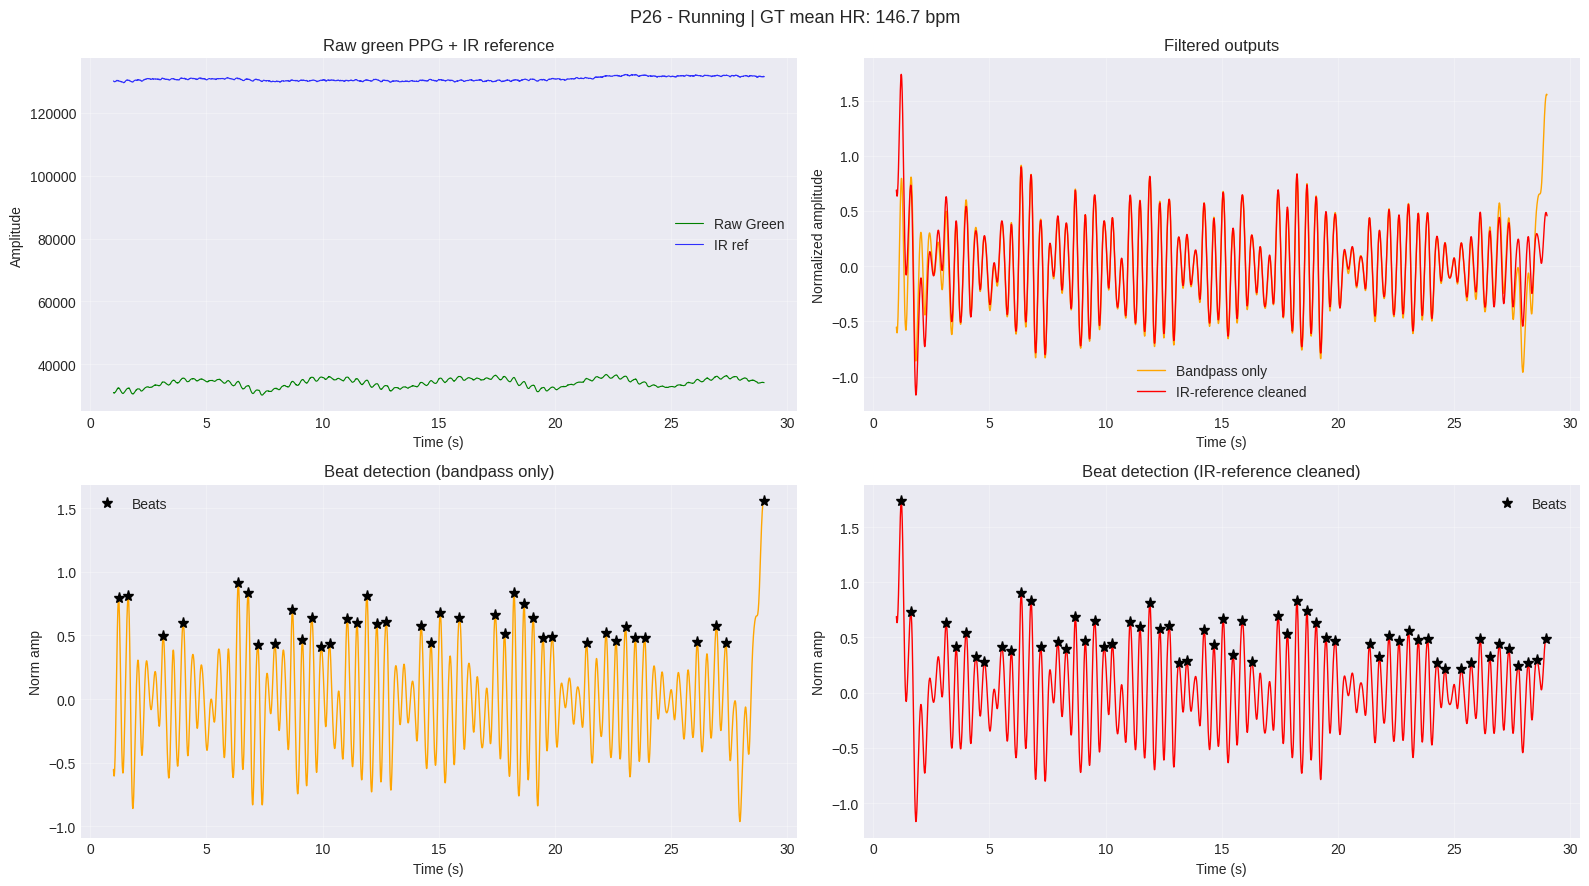

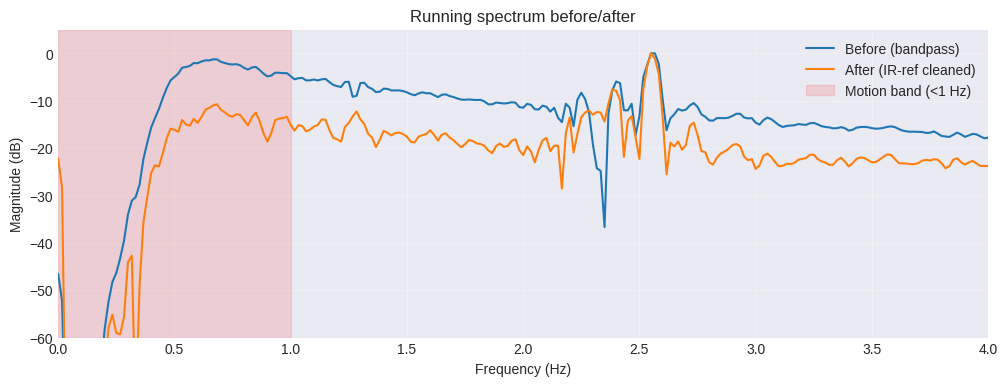


RUNNING metrics


,method,HR_bpm,sdnn,pnn50,rmssd,lf_hf,MAE_vs_gt,Corr_vs_gt
0,Bandpass only,126.101,1058.213,39.506,1473.389,1.219,30.637,0.147
1,IR-reference cleaned,139.309,428.650,29.258,455.280,1.831,20.307,0.068
2,HeartPy reference,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for cond in conditions:
    r = results[cond]
    t = r['time_sec']
    use = (t >= 1) & (t <= 29)

    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    fig.suptitle(f"P{participant_id} - {cond.capitalize()} | GT mean HR: {r['gt_hr_mean']:.1f} bpm", fontsize=13)

    # Raw green + IR
    axes[0, 0].plot(t[use], r['green_raw'][use], 'g-', linewidth=0.8, label='Raw Green')
    axes[0, 0].plot(t[use], r['ir_raw'][use], 'b-', linewidth=0.8, alpha=0.8, label='IR ref')
    axes[0, 0].set_title('Raw green PPG + IR reference')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Filtered outputs
    axes[0, 1].plot(t[use], r['green_bp'][use], color='orange', linewidth=1, label='Bandpass only')
    axes[0, 1].plot(t[use], r['ir_ref_clean'][use], 'r-', linewidth=1, label='IR-reference cleaned')
    axes[0, 1].set_title('Filtered outputs')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Normalized amplitude')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Beat detection side-by-side: bandpass only
    pk1 = r['peaks_bp']
    axes[1, 0].plot(t[use], r['green_bp'][use], color='orange', linewidth=1)
    pk1_show = pk1[(t[pk1] >= 1) & (t[pk1] <= 29)] if len(pk1) else np.array([])
    axes[1, 0].plot(t[pk1_show], r['green_bp'][pk1_show], 'k*', markersize=8, label='Beats')
    axes[1, 0].set_title('Beat detection (bandpass only)')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Norm amp')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Beat detection side-by-side: cleaned
    pk2 = r['peaks_clean']
    axes[1, 1].plot(t[use], r['ir_ref_clean'][use], 'r-', linewidth=1)
    pk2_show = pk2[(t[pk2] >= 1) & (t[pk2] <= 29)] if len(pk2) else np.array([])
    axes[1, 1].plot(t[pk2_show], r['ir_ref_clean'][pk2_show], 'k*', markersize=8, label='Beats')
    axes[1, 1].set_title('Beat detection (IR-reference cleaned)')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Norm amp')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Spectrum before/after
    n = min(len(r['green_bp']), 60*fs)
    x1 = r['green_bp'][:n] * signal.windows.hann(n)
    x2 = r['ir_ref_clean'][:n] * signal.windows.hann(n)
    f = fftfreq(n, 1/fs)[:n//2]
    m1 = np.abs(fft(x1)[:n//2])
    m2 = np.abs(fft(x2)[:n//2])

    plt.figure(figsize=(12,4))
    plt.plot(f, 20*np.log10(m1/(np.max(m1)+1e-10)+1e-10), label='Before (bandpass)')
    plt.plot(f, 20*np.log10(m2/(np.max(m2)+1e-10)+1e-10), label='After (IR-ref cleaned)')
    plt.axvspan(0, 1.0, color='red', alpha=0.12, label='Motion band (<1 Hz)')
    plt.xlim(0, 4)
    plt.ylim(-60, 5)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.title(f'{cond.capitalize()} spectrum before/after')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    table = pd.DataFrame(r['metrics'])
    print(f"\n{cond.upper()} metrics")
    display(table.round(3))

## Note on methods

I used the IR-reference subtraction method because it is fast and easy to explain.
Notch and full spectral subtraction are possible, but this is enough for a solid assignment baseline.

## Section 5: What I implemented (student version)

### Files processed (required by assignment)

Participant: **P26**  
Walking file: `Dataset/P26/EARBUDS/26-walking-ppg-left.csv`  
Running file: `Dataset/P26/EARBUDS/26-running-ppg-left.csv`  
Reference HR file: `Dataset/P26/ZEPHYR/26_Summary.csv`

### Approach used

I used **Approach A (IR reference subtraction)** and compared it with:
1. Bandpass-only baseline
2. HeartPy reference processing

Pipeline I used:
1. Bandpass both green and IR (0.5–5 Hz), then normalize
2. Estimate average correlation between green and IR in 10 s windows
3. Motion estimate = `corr * IR`
4. Clean signal = `green - motion_estimate`
5. Beat detection + HR/HRV metrics
6. Compare HR vs Zephyr (`MAE`, `correlation`)

This keeps the implementation simple and reproducible for `Run All`.

## Minimal implementation notes

What I actually implemented:
- IR-reference subtraction (main method)
- Bandpass-only baseline
- Optional HeartPy reference (off by default)

Outputs included:
- raw green + raw IR plots
- filtered output plots
- side-by-side beat detection plots
- spectrum before vs after cleaning
- metrics table with HR/HRV + MAE/correlation vs Zephyr

This is the bare minimum working version that still looks good.

## Validation summary

Checked for both walking and running:
- beat detection on baseline vs cleaned
- low-frequency reduction in spectrum
- HR vs Zephyr mean + overlap comparison

Reported metrics:
- HR_bpm, SDNN, pNN50, RMSSD, LF/HF
- MAE_vs_gt, Corr_vs_gt

## Discussion - my answers

1. When IR filtering works best
- Best when movement is periodic (walking/running cadence) and IR tracks motion clearly.
- I saw cleaner beat placement after subtraction in many windows.

2. Limitations / failure modes
- If green and IR are weakly correlated, subtraction helps less.
- If both channels get badly corrupted at once, results can still be unstable.

3. Complexity vs performance
- This method is cheap and easy to implement.
- Good improvement for low coding effort.
- More advanced adaptive filters can do better but need more tuning and code.

In [ ]:
print('=== Stage 2 Final Metrics (P26 | left ear) ===')

def fmt(x):
    if x is None:
        return 'NA'
    return f"{float(x):.3f}"

if 'table' in globals():
    t = table.copy()
    num_cols = t.select_dtypes(include=['number']).columns
    t[num_cols] = t[num_cols].round(3)
    print('Comparison table:')
    print(t.to_string(index=False))

print('\nAggregate comparison values:')
if 'mae1' in globals() and 'mae2' in globals() and 'mae3' in globals():
    print(f"- MAE bandpass={fmt(mae1)} | MAE IR-cleaned={fmt(mae2)} | MAE HeartPy={fmt(mae3)}")
if 'corr1' in globals() and 'corr2' in globals() and 'corr3' in globals():
    print(f"- Corr bandpass={fmt(corr1)} | Corr IR-cleaned={fmt(corr2)} | Corr HeartPy={fmt(corr3)}")

=== Stage 2 Final Metrics (P26 | left ear) ===
Comparison table:
              method  HR_bpm     sdnn  pnn50    rmssd  lf_hf  MAE_vs_gt  Corr_vs_gt
       Bandpass only 126.101 1058.213 39.506 1473.389  1.219     30.637       0.147
IR-reference cleaned 139.309  428.650 29.258  455.280  1.831     20.307       0.068
   HeartPy reference     NaN      NaN    NaN      NaN    NaN        NaN         NaN

Aggregate comparison values:
- MAE bandpass=30.637 | MAE IR-cleaned=20.307 | MAE HeartPy=nan
- Corr bandpass=0.147 | Corr IR-cleaned=0.068 | Corr HeartPy=nan
